# Classifying the agent archetype from the embedded card space

**Question.** cardseq_embed.py turned each card's rules-text into a 24-d LSA
vector and then hardened those vectors into 12 *role* clusters. Here we skip the
hardening: each game is represented by the **mean of the embedding vectors of the
cards the agent (me-side) actually played** -- a single point in the same card
space -- and we ask a classifier to name the agent's **playstyle archetype**
(`aggro / midrange / fatigue / control / ramp`, 5 classes, chance = 0.200).

**Why this representation.** The mean-pooled vector is a soft, continuous
"card-mix centroid". It keeps *function* (what the played cards do) without
committing to a fixed number of roles, so it should be at least as expressive as
`role_frac_*` while staying deck-agnostic in principle.

**Evaluation (two lenses).**
1. *Deck-safety yardsticks* -- identical to `cardseq_embed` / `cardseq_metrics`:
   normalized MI `U_style` vs `U_deck` per dimension, within-deck 5-fold accuracy,
   and cross-deck transfer (train on one deck, test on the other).
2. *Confusion matrix + per-class report* for the headline model, both
   within-distribution and under a deck shift.

Everything is written to `Log_Analysis_Simulated/embed_out/`.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

# make cardseq_embed importable no matter the launch directory
HERE = Path.cwd()
for cand in [HERE, HERE / "Log_Analysis_Simulated", Path(__file__).parent if "__file__" in dir() else HERE]:
    if (cand / "cardseq_embed.py").exists() and str(cand) not in sys.path:
        sys.path.insert(0, str(cand)); break
import cardseq_embed as ce

OUT = ce.OUT_DIR; OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 200, "display.max_columns", 40)
print("data root :", ce.ROOT)
print("out dir   :", OUT)

data root : D:\test
out dir   : D:\test\Log_Analysis_Simulated\embed_out


## 1. Rebuild the card embedding space

Same pipeline as `cardseq_embed.embed_and_cluster`, but we keep the per-card
vectors keyed by card id (`emb[key] -> 24-d vector`) instead of clustering them.
Both sides' played cards define the space; only the me-side is pooled per game.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

by_id, by_name = ce.load_card_docs()
sim = json.loads(ce.SIM_JSON.read_text(encoding="utf-8"))
vocab = ce.played_cards(sim, by_id, by_name)

docs_rows = [(k, nm, doc, c) for (k, nm, doc, c) in vocab if doc]
keys = [k for (k, _n, _d, _c) in docs_rows]
docs = [d for (_k, _n, d, _c) in docs_rows]

vec = TfidfVectorizer(min_df=1, token_pattern=r"[a-z0-9_]+")
X = vec.fit_transform(docs)
dim = min(ce.EMBED_DIM, X.shape[1] - 1, len(docs) - 1)
svd = TruncatedSVD(n_components=max(2, dim), random_state=ce.SEED)
Z = svd.fit_transform(X)
Z = Z / np.maximum(np.linalg.norm(Z, axis=1, keepdims=True), 1e-9)   # L2-normalize, as in cardseq_embed
emb = {k: Z[i] for i, k in enumerate(keys)}
EMB_D = Z.shape[1]
print(f"card embedding: {len(emb)} cards x {EMB_D}d "
      f"(TF-IDF {X.shape}, explained var {svd.explained_variance_ratio_.sum():.2f})")

Card docs: 8305 ids / 6494 names (4831 ids gap-filled)
Played vocabulary: 391 distinct cards (0 without a document)


card embedding: 391 cards x 24d (TF-IDF (391, 405), explained var 0.43)


## 2. One mean-pooled vector per game

For each game we average the embedding vectors of the cards the me-side played
(Coin excluded). `pooled_cards` audits how many plays landed in the space; in
this dataset every played card has a document, so it should be ~all of them.

In [3]:
def game_vector(game, emb, d):
    vs = []
    for h in game["card_history"]:
        if h.get("player") != "me":
            continue
        card = h.get("card", {})
        name = card.get("name")
        if not name or name == ce.COIN_NAME:
            continue
        key = card.get("id") or name
        v = emb.get(key)
        if v is not None:
            vs.append(v)
    return (np.mean(vs, axis=0) if vs else np.full(d, np.nan)), len(vs)

emb_cols = [f"emb_{i}" for i in range(EMB_D)]
rows = []
for g in sim["games"]:
    v, npool = game_vector(g, emb, EMB_D)
    row = {c: v[i] for i, c in enumerate(emb_cols)}
    row.update(style=g["hero_playstyle"], deck=g["hero_deck"],
               result=g.get("result"), pooled_cards=npool)
    rows.append(row)
df = pd.DataFrame(rows)
df.to_csv(OUT / "game_embeddings.csv", index=False)

print(f"{len(df)} games x {EMB_D} embedding dims  "
      f"(mean pooled cards/game = {df.pooled_cards.mean():.1f}, "
      f"{(df.pooled_cards == 0).sum()} empty)")
print("\nplaystyle balance:\n", df["style"].value_counts())
print("\ndeck balance:\n", df["deck"].value_counts())

8988 games x 24 embedding dims  (mean pooled cards/game = 9.7, 3 empty)

playstyle balance:
 style
aggro       1799
midrange    1799
fatigue     1798
control     1797
ramp        1795
Name: count, dtype: int64

deck balance:
 deck
AggroPirateWarrior    4500
RenoKazakusMage       4488
Name: count, dtype: int64


## 3. Lens A -- deck-safety yardsticks

`ce.discriminativeness` gives, per embedding dimension, the normalized MI with
**style** vs with **deck** (`U_gap = U_style - U_deck`, positive = more style
than deck) and the cross-deck profile correlation (+1 = the dimension means the
same thing on both decks). `ce.classifier_check` runs the same RandomForest as
the rest of the project: within-deck 5-fold and cross-deck transfer.

In [4]:
rank = ce.discriminativeness(df, emb_cols)
rank.round(4).to_csv(OUT / "embed_playstyle_ranking.csv", index=False)
print("per-dimension style signal vs deck leakage (top by U_style):")
print(rank.round(3).to_string(index=False))
print(f"\nTOTAL  U_style={rank.U_style.sum():.3f}  U_deck={rank.U_deck.sum():.3f}  "
      f"U_gap={rank.U_gap.sum():+.3f}")

per-dimension style signal vs deck leakage (top by U_style):
feature  U_style  U_deck  U_gap  cross_deck_profile_corr
 emb_13    0.045   0.177 -0.131                    0.244
 emb_14    0.045   0.091 -0.047                    0.950
 emb_16    0.039   0.501 -0.462                   -0.907
 emb_21    0.037   0.559 -0.522                    0.102
 emb_15    0.034   0.674 -0.639                   -0.912
 emb_22    0.034   0.259 -0.225                    0.878
 emb_19    0.032   0.401 -0.369                   -0.423
  emb_4    0.032   0.827 -0.795                   -0.522
 emb_12    0.032   0.535 -0.503                   -0.560
  emb_2    0.029   0.844 -0.815                    0.740
 emb_10    0.029   0.461 -0.432                    0.686
  emb_9    0.028   0.043 -0.014                    0.848
 emb_18    0.028   0.771 -0.743                   -0.603
  emb_6    0.026   0.309 -0.282                    0.563
  emb_0    0.025   0.715 -0.690                   -0.890
  emb_3    0.025   0.645 -0

In [5]:
# headline model: mean-pooled embedding
emb_scores = ce.classifier_check(df, emb_cols, label="mean-pooled embedding (this notebook)")

# baseline for comparison: the 12 HARD role fractions from cardseq_embed.py
role_df = pd.read_csv(OUT / "role_features.csv")
role_feats = [c for c in role_df.columns if c not in {"style", "deck", "result"}]
role_scores = ce.classifier_check(role_df, role_feats, label="hard role fractions (cardseq_embed baseline)")


=== classifier check (mean-pooled embedding (this notebook)) --- chance = 0.200 ===
  within_AggroPirateWarrior_5fold    0.274
  within_RenoKazakusMage_5fold       0.403
  transfer_Aggr->Reno                0.209
  transfer_Reno->Aggr                0.210



=== classifier check (hard role fractions (cardseq_embed baseline)) --- chance = 0.200 ===
  within_AggroPirateWarrior_5fold    0.256
  within_RenoKazakusMage_5fold       0.349
  transfer_Aggr->Reno                0.210
  transfer_Reno->Aggr                0.204


## 4. Lens B -- confusion matrix + per-class report

Headline model = RandomForest on the mean-pooled embedding. Three panels:

* **within-distribution** -- 5-fold out-of-fold predictions over both decks
  mixed (what the model *can* do when train and test share the deck mix);
* **transfer Aggro to Reno** and **Reno to Aggro** -- trained on one deck, tested
  on the other (the honest deck-shift picture). Rows are normalized to recall.

within-distribution 5-fold classification report:

              precision    recall  f1-score   support

       aggro      0.475     0.558     0.513      1799
     control      0.290     0.259     0.273      1797
     fatigue      0.357     0.354     0.356      1798
    midrange      0.263     0.237     0.249      1799
        ramp      0.313     0.326     0.320      1795

    accuracy                          0.347      8988
   macro avg      0.340     0.347     0.342      8988
weighted avg      0.340     0.347     0.342      8988



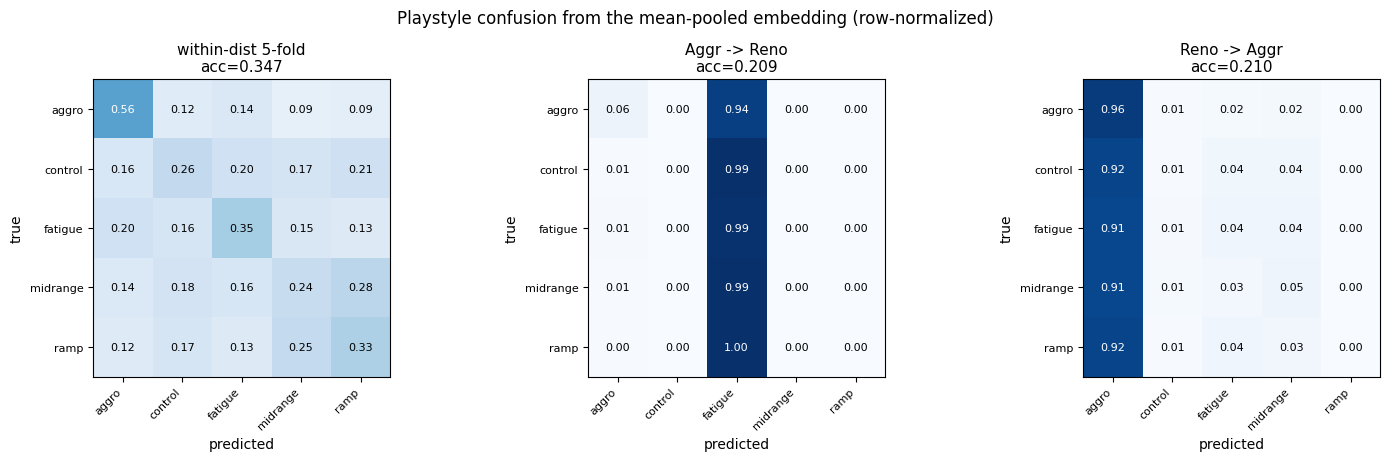

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

STYLES = sorted(df["style"].unique())
def rf():
    return make_pipeline(SimpleImputer(strategy="median"),
                         RandomForestClassifier(n_estimators=200, random_state=ce.SEED, n_jobs=-1))

X_all = df[emb_cols].replace([np.inf, -np.inf], np.nan).to_numpy()
y_all = df["style"].to_numpy()

# within-distribution out-of-fold predictions
oof = cross_val_predict(rf(), X_all, y_all,
                        cv=StratifiedKFold(5, shuffle=True, random_state=ce.SEED), n_jobs=-1)
print("within-distribution 5-fold classification report:\n")
print(classification_report(y_all, oof, labels=STYLES, digits=3, zero_division=0))

# cross-deck predictions
decks = sorted(df.deck.unique())
def transfer_pred(tr, te):
    m = rf().fit(df[df["deck"] == tr][emb_cols].to_numpy(), df[df["deck"] == tr]["style"].to_numpy())
    sub = df[df["deck"] == te]
    return sub["style"].to_numpy(), m.predict(sub[emb_cols].to_numpy())
yA, pA = transfer_pred(decks[0], decks[1])
yB, pB = transfer_pred(decks[1], decks[0])

panels = [("within-dist 5-fold", y_all, oof),
          (f"{decks[0][:4]} -> {decks[1][:4]}", yA, pA),
          (f"{decks[1][:4]} -> {decks[0][:4]}", yB, pB)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (title, yt, yp) in zip(axes, panels):
    cm = confusion_matrix(yt, yp, labels=STYLES).astype(float)
    cm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    acc = (yt == yp).mean()
    ax.set_title(f"{title}\nacc={acc:.3f}", fontsize=11)
    ax.set_xticks(range(len(STYLES))); ax.set_xticklabels(STYLES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(STYLES))); ax.set_yticklabels(STYLES, fontsize=8)
    for i in range(len(STYLES)):
        for j in range(len(STYLES)):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if cm[i, j] > 0.5 else "black")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
fig.suptitle("Playstyle confusion from the mean-pooled embedding (row-normalized)", fontsize=12)
fig.tight_layout()
fig.savefig(OUT / "fig_embed_confusion.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Does the embedded game-space separate by style or by deck?

A 2-D PCA of the per-game mean-pooled vectors, coloured two ways. If the point
cloud splits by **deck** (right) but not by **style** (left), the embedded space
is still carrying deck identity -- the project's recurring failure mode.

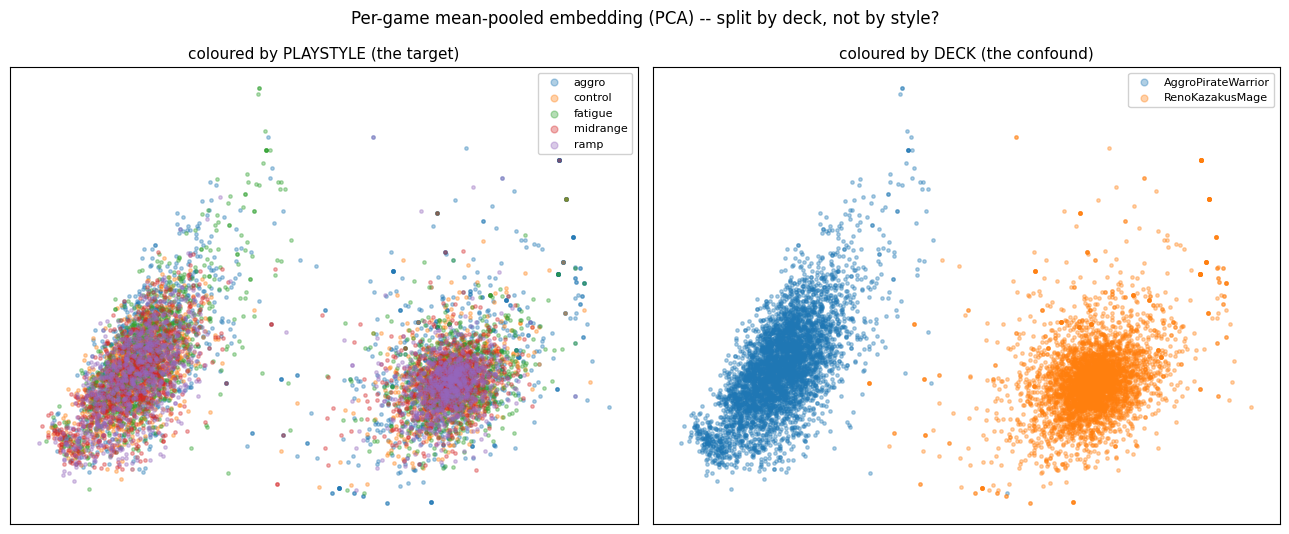

In [7]:
from sklearn.decomposition import PCA

Xg = df[emb_cols].fillna(df[emb_cols].median()).to_numpy()
P = PCA(n_components=2, random_state=ce.SEED).fit_transform(Xg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharex=True, sharey=True)
for grp, ax, title in [("style", axes[0], "coloured by PLAYSTYLE (the target)"),
                       ("deck", axes[1], "coloured by DECK (the confound)")]:
    for lab in sorted(df[grp].unique()):
        m = (df[grp] == lab).to_numpy()
        ax.scatter(P[m, 0], P[m, 1], s=6, alpha=0.35, label=lab)
    ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
    ax.legend(markerscale=2, fontsize=8, framealpha=0.9)
fig.suptitle("Per-game mean-pooled embedding (PCA) -- split by deck, not by style?", fontsize=12)
fig.tight_layout()
fig.savefig(OUT / "fig_embed_game_space.png", dpi=130, bbox_inches="tight")
plt.show()

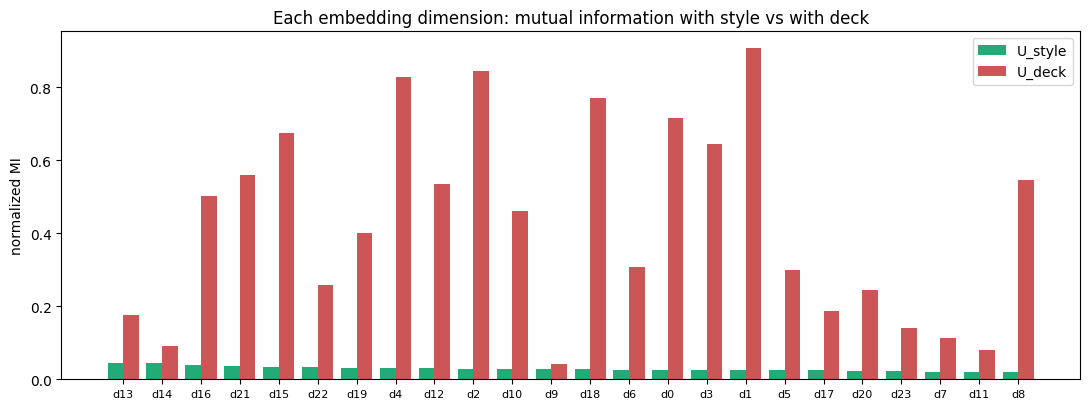

In [8]:
# per-dimension MI: how much of each embedding axis is style vs deck
r = rank.set_index("feature").loc[emb_cols]
order = r.U_style.sort_values(ascending=False).index
x = np.arange(len(order)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(x - w/2, r.loc[order, "U_style"], w, label="U_style", color="#2a7")
ax.bar(x + w/2, r.loc[order, "U_deck"], w, label="U_deck", color="#c55")
ax.set_xticks(x); ax.set_xticklabels([c.replace("emb_", "d") for c in order], fontsize=8)
ax.set_ylabel("normalized MI"); ax.legend()
ax.set_title("Each embedding dimension: mutual information with style vs with deck")
fig.tight_layout()
fig.savefig(OUT / "fig_embed_style_vs_deck_mi.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Verdict

In [9]:
def mean_within(scores):
    return np.mean([v for k, v in scores.items() if k.startswith("within_")])
def mean_transfer(scores):
    return np.mean([v for k, v in scores.items() if k.startswith("transfer_")])

summary = pd.DataFrame({
    "representation": ["mean-pooled embedding (24d)", "hard role fractions (15d)"],
    "within_deck_acc": [mean_within(emb_scores), mean_within(role_scores)],
    "cross_deck_acc":  [mean_transfer(emb_scores), mean_transfer(role_scores)],
}).round(3)
summary["vs_chance_within"] = (summary.within_deck_acc - 0.2).round(3)
print(summary.to_string(index=False))
print(f"\nembedding MI totals: U_style={rank.U_style.sum():.3f}  "
      f"U_deck={rank.U_deck.sum():.3f}  gap={rank.U_gap.sum():+.3f}")
print("chance = 0.200 | within = train & test share deck mix | cross = deck shift")

             representation  within_deck_acc  cross_deck_acc  vs_chance_within
mean-pooled embedding (24d)            0.338           0.210             0.138
  hard role fractions (15d)            0.303           0.207             0.103

embedding MI totals: U_style=0.700  U_deck=10.327  gap=-9.626
chance = 0.200 | within = train & test share deck mix | cross = deck shift


**How to read it.** If `within_deck_acc` beats chance but `cross_deck_acc`
collapses toward 0.200, and the MI totals show `U_deck >> U_style`, then the
mean-pooled embedding is recognising the *deck* the archetype tends to pilot, not
a deck-independent *style*. That is the same conclusion the role fractions and
the hand-made cardseq metrics reached -- soft-pooling the card text does not, by
itself, disentangle style from deck. The confusion panels show *where* it breaks:
within-distribution the classes are mostly separable, but under a deck shift the
predictions collapse onto whichever styles the training deck over-represents.

See `embed_out/` for `game_embeddings.csv`, `embed_playstyle_ranking.csv`, and the
three figures.